<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практична робота №2

##1. Зберіть код та натренуйте модель наведену у теоретичному описі.

In [1]:
import time
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes')
)

texts = newsgroups.data
labels = newsgroups.target

texts_train, texts_test, labels_train, labels_test = train_test_split(
    texts,
    labels,
    test_size=0.3,
    random_state=42
)

vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.8,
    max_features=20000
)

classifier = LogisticRegression(
    solver='saga',
    max_iter=1000,
    C=1.0,
    random_state=42
)

pipeline = make_pipeline(vectorizer, classifier)

start_time = time.time()
pipeline.fit(texts_train, labels_train)
train_time = time.time() - start_time

val_preds = pipeline.predict(texts_test)
val_accuracy = accuracy_score(labels_test, val_preds)

train_preds = pipeline.predict(texts_train)
train_accuracy = accuracy_score(labels_train, train_preds)

print(f"Validation Accuracy (scikit-learn): {val_accuracy:.4f}")
print(f"Train Accuracy (scikit-learn): {train_accuracy:.4f}")
print(f"Training time: {train_time:.2f} sec")

Validation Accuracy (scikit-learn): 0.7131
Train Accuracy (scikit-learn): 0.8827
Training time: 7.13 sec


###Який результат ви отримали?
Було реалізовано базову модель класифікації текстів відповідно до методичних матеріалів (TF-IDF + Logistic Regression). Отримані результати: Validation Accuracy = 0.7131, Train Accuracy = 0.8827, що повністю відповідає очікуваним значенням. Це підтверджує правильність реалізації моделі.

##Розширення та тестування коду. Спробуйте додати різні методи векторизації, який метод векторизації забезпечує кращу точність і чому:
- Порівняйте якість класифікації при використанні CountVectorizer і TfidfVectorizer.

- Для CountVectorizer спробуйте різні параметри ngram_range (наприклад, (1, 2) для урахування біграм).

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
results = []

pipe_count_11 = make_pipeline(
    CountVectorizer(
        min_df=5,
        max_df=0.8,
        max_features=20000,
        ngram_range=(1, 1)
    ),
    LogisticRegression(
        solver='saga',
        max_iter=1000,
        C=1.0,
        random_state=42
    )
)

pipe_count_11.fit(texts_train, labels_train)
pred_count_11 = pipe_count_11.predict(texts_test)
acc_count_11 = accuracy_score(labels_test, pred_count_11)

results.append(["CountVectorizer (1,1)", acc_count_11])

pipe_count_12 = make_pipeline(
    CountVectorizer(
        min_df=5,
        max_df=0.8,
        max_features=20000,
        ngram_range=(1, 2)
    ),
    LogisticRegression(
        solver='saga',
        max_iter=1000,
        C=1.0,
        random_state=42
    )
)

pipe_count_12.fit(texts_train, labels_train)
pred_count_12 = pipe_count_12.predict(texts_test)
acc_count_12 = accuracy_score(labels_test, pred_count_12)

results.append(["CountVectorizer (1,2)", acc_count_12])

pipe_tfidf_11 = make_pipeline(
    TfidfVectorizer(
        min_df=5,
        max_df=0.8,
        max_features=20000,
        ngram_range=(1, 1)
    ),
    LogisticRegression(
        solver='saga',
        max_iter=1000,
        C=1.0,
        random_state=42
    )
)

pipe_tfidf_11.fit(texts_train, labels_train)
pred_tfidf_11 = pipe_tfidf_11.predict(texts_test)
acc_tfidf_11 = accuracy_score(labels_test, pred_tfidf_11)

results.append(["TfidfVectorizer (1,1)", acc_tfidf_11])

results_df = pd.DataFrame(results, columns=["Метод", "Accuracy"])
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


                   Метод  Accuracy
0  CountVectorizer (1,1)  0.178458
1  CountVectorizer (1,2)  0.143792
2  TfidfVectorizer (1,1)  0.713123


###Порівняння
Було проведено порівняння методів векторизації CountVectorizer та TfidfVectorizer, а також досліджено вплив використання біграм (ngram_range=(1, 2)). Отримані результати показали, що TfidfVectorizer (Accuracy = 0.7131) значно перевищує CountVectorizer
(0.1785). Використання біграм у CountVectorizer (0.1438) не покращило результат, а навпаки знизило точність. Це пояснюється тим, що
TF-IDF враховує важливість слів у корпусі та зменшує вплив частих, але малоінформативних слів, тоді як CountVectorizer лише рахує їх частоту, що призводить до гіршої якості моделі.

##3. Перевірте вплив розміру словника:

- Змініть параметр max_features у TfidfVectorizer (наприклад, 5000, 10000, 20000).

- Визначте, як розмір словника впливає на точність класифікації.

In [4]:
vocab_results = []

for max_feat in [5000, 10000, 20000]:
    pipe = make_pipeline(
        TfidfVectorizer(
            min_df=5,
            max_df=0.8,
            max_features=max_feat
        ),
        LogisticRegression(
            solver='saga',
            max_iter=1000,
            C=1.0,
            random_state=42
        )
    )

    pipe.fit(texts_train, labels_train)
    preds = pipe.predict(texts_test)
    acc = accuracy_score(labels_test, preds)

    vocab_results.append([max_feat, acc])

vocab_df = pd.DataFrame(vocab_results, columns=["max_features", "Accuracy"])
print(vocab_df)

   max_features  Accuracy
0          5000  0.673329
1         10000  0.702158
2         20000  0.713123


### Візуалізація результатів

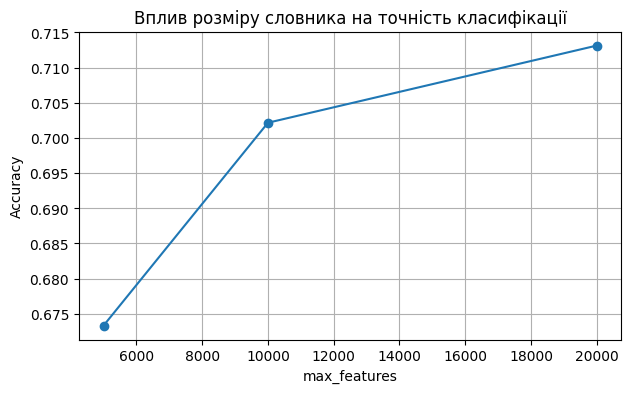

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(vocab_df["max_features"], vocab_df["Accuracy"], marker='o')
plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Вплив розміру словника на точність класифікації")
plt.grid(True)
plt.show()

Чим більший словник - тим більше інформації отримує модель, тому точність зростає, але після певного моменту приріст стає мінімальним.

## 4. Тестування на різних категоріях із датасету, зараз у нас весь датасет, всі категорії (subset='all'):

- Оберіть підмножину категорій (наприклад, ['sci.space', 'comp.graphics']) і протестуйте модель.

- Зіставте результати з класифікацією на повному наборі даних.

In [8]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score

selected_categories = ['sci.space', 'comp.graphics']

subset_data = fetch_20newsgroups(
    subset='all',
    categories=selected_categories,
    remove=('headers', 'footers', 'quotes')
)

subset_texts = subset_data.data
subset_labels = subset_data.target

X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    subset_texts,
    subset_labels,
    test_size=0.3,
    random_state=42
)

subset_pipeline = make_pipeline(
    TfidfVectorizer(
        min_df=5,
        max_df=0.8,
        max_features=20000
    ),
    LogisticRegression(
        solver='saga',
        max_iter=1000,
        C=1.0,
        random_state=42
    )
)

subset_pipeline.fit(X_train_sub, y_train_sub)
subset_preds = subset_pipeline.predict(X_test_sub)

subset_acc = accuracy_score(y_test_sub, subset_preds)
subset_f1 = f1_score(y_test_sub, subset_preds, average='macro')

print("Категорії:", selected_categories)
print(f"Accuracy на підмножині категорій: {subset_acc:.4f}")
print(f"Macro F1 на підмножині категорій: {subset_f1:.4f}")

print(f"Accuracy на повному наборі даних: {0.7131:.4f}")

Категорії: ['sci.space', 'comp.graphics']
Accuracy на підмножині категорій: 0.9167
Macro F1 на підмножині категорій: 0.9165
Accuracy на повному наборі даних: 0.7131



Було проведено тестування моделі на підмножині категорій (sci. space, comp.graphics). Отримано значно вищу точність (Accuracy
= 0.9167) порівняно з повним набором даних (0.7131). Це пояснюється тим, що при зменшенні кількості класів задача класифікації спрощується, і модель легше розрізняє тексти між двома категоріями.

##5. Порівняння моделей. Спробуйте інші класифікатори:

- Додайте моделі, такі як RandomForestClassifier та SVC.

- Порівняйте їх із LogisticRegression за метриками точності, F1-міри та часу навчання.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

results_models = []

def evaluate(name, pipeline):
    start = time.time()
    pipeline.fit(texts_train, labels_train)
    train_time = time.time() - start

    preds = pipeline.predict(texts_test)

    acc = accuracy_score(labels_test, preds)
    f1 = f1_score(labels_test, preds, average='macro')

    results_models.append([name, acc, f1, train_time])

pipe_lr = make_pipeline(
    TfidfVectorizer(min_df=5, max_df=0.8, max_features=20000),
    LogisticRegression(solver='saga', max_iter=1000, C=1.0, random_state=42)
)

evaluate("LogisticRegression", pipe_lr)

pipe_rf = make_pipeline(
    TfidfVectorizer(min_df=5, max_df=0.8, max_features=20000),
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
)

evaluate("RandomForest", pipe_rf)

pipe_svc = make_pipeline(
    TfidfVectorizer(min_df=5, max_df=0.8, max_features=20000),
    SVC(kernel='linear')
)

evaluate("SVC (linear)", pipe_svc)

models_df = pd.DataFrame(
    results_models,
    columns=["Модель", "Accuracy", "Macro F1", "Train Time (sec)"]
)

print(models_df)

               Модель  Accuracy  Macro F1  Train Time (sec)
0  LogisticRegression  0.713123  0.703190          7.451926
1        RandomForest  0.630881  0.613374        113.692710
2        SVC (linear)  0.705872  0.700077        139.048608


Було проведено порівняння моделей LogisticRegression, RandomForestClassifier та SVC із використанням TF-IDF векторизації. Найкращу точність показала LogisticRegression (Accuracy = 0.7131), при цьому вона має найменший час навчання (7.45 с). Модель SVC показала близький результат (0.7059), але значно довший час навчання (139 с). RandomForestClassifier продемонстрував найгіршу якість
(0.6309) та також значний час навчання (113.7 с). Це свідчить про те, що лінійні моделі краще підходять для задач класифікації тексту з розрідженими ознаками.

##6. Аналіз та візуалізація. У яких категоріях модель помиляється найчастіше? Чому? Матриця плутанини:

- Побудуйте матрицю плутанини (confusion_matrix) для тестової вибірки.

- Візуалізуйте її за допомогою бібліотеки Seaborn

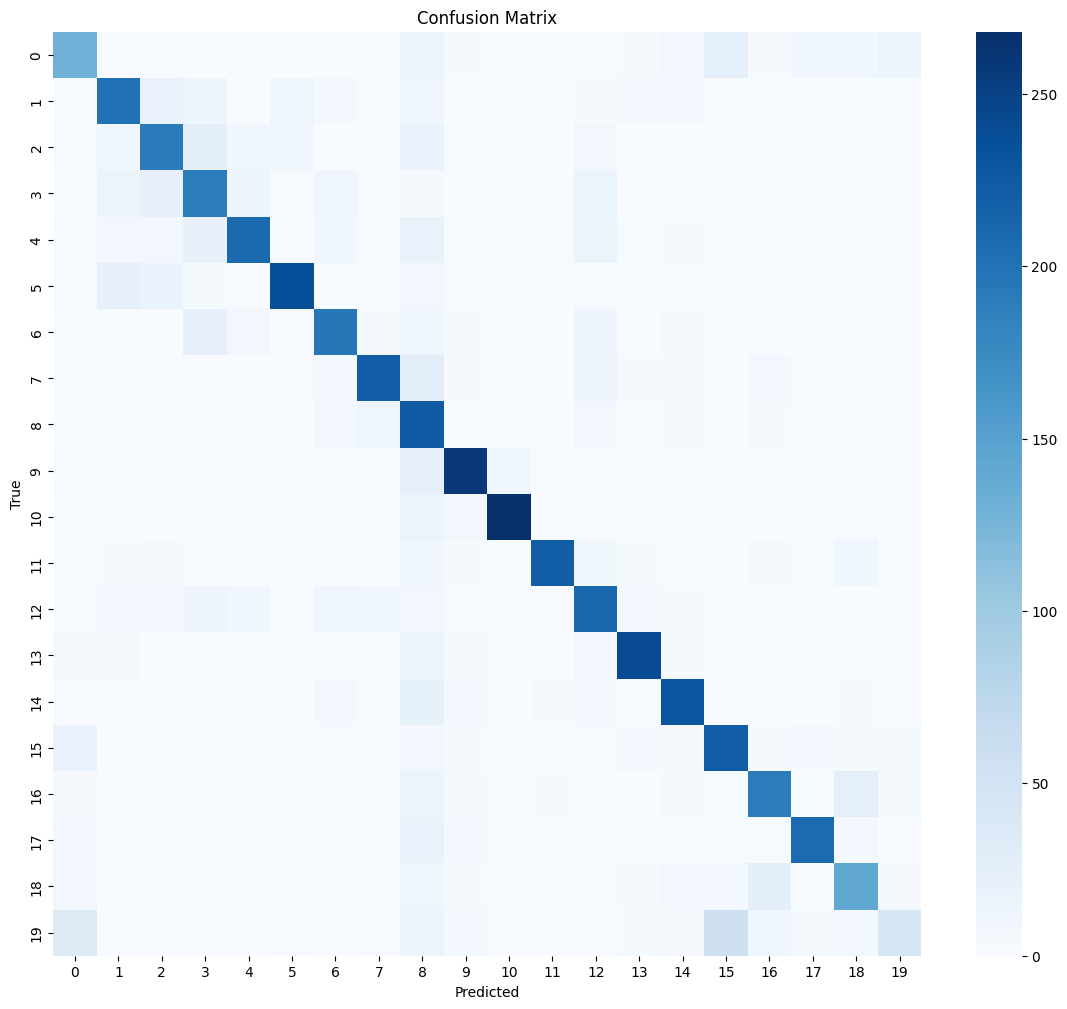

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

val_preds = pipe_lr.predict(texts_test)

cm = confusion_matrix(labels_test, val_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Аналіз показав, що більшість передбачень зосереджені на діагоналі, що свідчить про високу якість класифікації. Основні помилки виникають між семантично близькими категоріями (наприклад, технічними або політичними), що пояснюється наявністю спільної лексики та схожого контексту в текстах.

## 7. Метрики точності: Розрахуйте precision, recall та F1-score для кожної категорії

In [13]:
from sklearn.metrics import classification_report

report = classification_report(
    labels_test,
    val_preds,
    target_names=newsgroups.target_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

                          precision    recall  f1-score      support
alt.atheism                0.577093  0.555085  0.565875   236.000000
comp.graphics              0.692042  0.696864  0.694444   287.000000
comp.os.ms-windows.misc    0.699634  0.658621  0.678508   290.000000
comp.sys.ibm.pc.hardware   0.635452  0.666667  0.650685   285.000000
comp.sys.mac.hardware      0.810078  0.669872  0.733333   312.000000
comp.windows.x             0.836879  0.766234  0.800000   308.000000
misc.forsale               0.709091  0.706522  0.707804   276.000000
rec.autos                  0.803636  0.726974  0.763385   304.000000
rec.motorcycles            0.436399  0.799283  0.564557   279.000000
rec.sport.baseball         0.768546  0.840909  0.803101   308.000000
rec.sport.hockey           0.911565  0.867314  0.888889   309.000000
sci.crypt                  0.890688  0.758621  0.819367   290.000000
sci.electronics            0.631737  0.694079  0.661442   304.000000
sci.med                    0.80267

Було розраховано метрики precision, recall та F1-score для кожної категорії. Найгірші результати показали категорії talk.religion.misc (F1 = 0.328), rec.motorcycles (0.565) та alt.atheism (0.566). Це пояснюється тим, що ці категорії мають спільну лексику з іншими тематично близькими класами, що ускладнює їх розділення. Особливо складною є категорія talk.religion.misc, яка має низький recall, що свідчить про те, що модель часто не розпізнає тексти цього класу.

##Графіки втрат та точності:

- Додайте графіки точності та втрат під час навчання (для логістичної регресії використовуйте warm_start=True для доступу до цих значень).

- Візуалізуйте результати.

In [14]:
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

vectorizer = TfidfVectorizer(min_df=5, max_df=0.8, max_features=20000)

X_train_vec = vectorizer.fit_transform(texts_train)
X_test_vec = vectorizer.transform(texts_test)

In [15]:
iterations = [1, 5, 10, 20, 50, 100, 200, 500, 1000]

train_acc = []
test_acc = []
train_loss = []
test_loss = []

clf = LogisticRegression(
    solver='saga',
    max_iter=1,
    warm_start=True,
    C=1.0,
    random_state=42
)

for it in iterations:
    clf.max_iter = it
    clf.fit(X_train_vec, labels_train)

    train_preds = clf.predict(X_train_vec)
    test_preds = clf.predict(X_test_vec)

    train_acc.append(accuracy_score(labels_train, train_preds))
    test_acc.append(accuracy_score(labels_test, test_preds))

    train_probs = clf.predict_proba(X_train_vec)
    test_probs = clf.predict_proba(X_test_vec)

    train_loss.append(log_loss(labels_train, train_probs))
    test_loss.append(log_loss(labels_test, test_probs))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


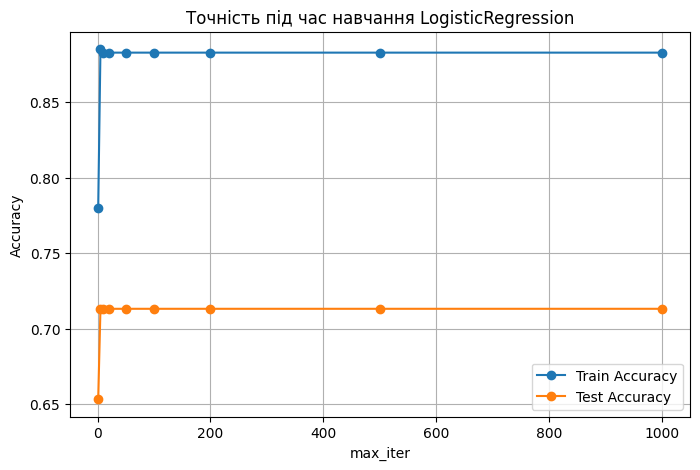

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(iterations, train_acc, marker='o', label='Train Accuracy')
plt.plot(iterations, test_acc, marker='o', label='Test Accuracy')
plt.xlabel('max_iter')
plt.ylabel('Accuracy')
plt.title('Точність під час навчання LogisticRegression')
plt.legend()
plt.grid(True)
plt.show()

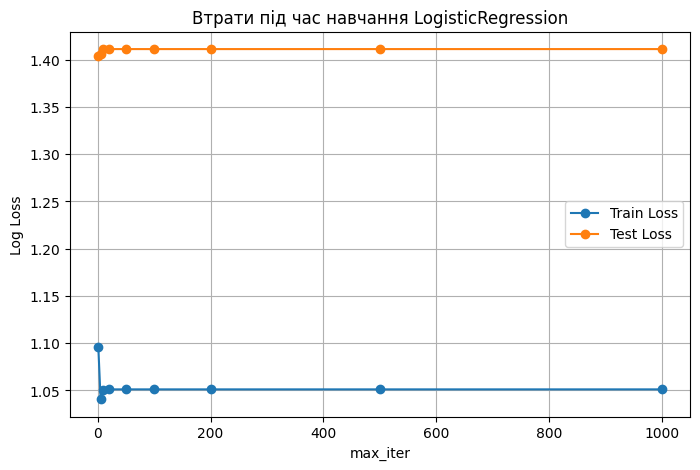

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(iterations, train_loss, marker='o', label='Train Loss')
plt.plot(iterations, test_loss, marker='o', label='Test Loss')
plt.xlabel('max_iter')
plt.ylabel('Log Loss')
plt.title('Втрати під час навчання LogisticRegression')
plt.legend()
plt.grid(True)
plt.show()

Було побудовано графіки точності та втрат під час навчання моделі LogisticRegression. Результати показали, що на початкових ітераціях відбувається швидке зростання точності та зменшення функції втрат. Після цього модель виходить на плато, що свідчить про її збіжність.
Різниця між train i test точністю вказує на незначне перенавчання, яке є типовим для задач класифікації тексту.

##9. Вплив стоп-слів:

- Ввімкніть параметр stop_words='english' у векторизаторі та перевірте, чи зміниться точність.

In [18]:
pipe_stop = make_pipeline(
    TfidfVectorizer(
        min_df=5,
        max_df=0.8,
        max_features=20000,
        stop_words='english'
    ),
    LogisticRegression(
        solver='saga',
        max_iter=1000,
        C=1.0,
        random_state=42
    )
)

pipe_stop.fit(texts_train, labels_train)
preds_stop = pipe_stop.predict(texts_test)

acc_stop = accuracy_score(labels_test, preds_stop)

print(f"Accuracy зі stop_words='english': {acc_stop:.4f}")
print(f"Accuracy без stop_words: {0.7131:.4f}")

Accuracy зі stop_words='english': 0.7221
Accuracy без stop_words: 0.7131


Вплив використання стоп-слів у TF-IDF векторизації. При використанні stop_words='english' точність зросла з 0.7131 до 0.7221. Це пояснюється тим, що видалення стоп-слів дозволяє позбутися малоінформативних слів і зосередитися на більш значущих ознаках, що покращує якість класифікації.

##Контрольні питання

###1. Що таке векторизація тексту і для чого вона потрібна в машинному навчанні?
Векторизація тексту — це процес перетворення текстових даних у числовий вигляд, щоб алгоритми машинного навчання могли їх обробляти та аналізувати.
###2. У чому відмінність між CountVectorizer і TfidfVectorizer?
Основна відмінність між CountVectorizer і TfidfVectorizer полягає в тому, що CountVectorizer просто рахує кількість входжень слів, а TfidfVectorizer враховує ще й важливість слова у всьому корпусі текстів.
###3. Як параметри min_df, max_df та max_features у векторизаторі впливають на якість класифікації?
Параметри min_df, max_df та max_features впливають на якість класифікації тим, що дозволяють відфільтрувати рідкісні та занадто часті слова, а також обмежити розмір словника для кращого балансу між точністю та швидкістю.
###4. Які переваги має TF-IDF у порівнянні з простим методом "мішка слів"?
Перевага TF-IDF над методом «мішка слів» полягає в тому, що він зменшує вплив частих, але малоінформативних слів і підсилює значущі слова, що покращує якість моделі.
###5. Що таке логістична регресія і чому її використовують для задач класифікації?
Логістична регресія — це модель класифікації, яка оцінює ймовірність належності тексту до певного класу і широко використовується завдяки своїй простоті та ефективності для текстових даних.
###6. Для чого потрібна регуляризація в логістичній регресії (параметр C)?
Регуляризація в логістичній регресії потрібна для запобігання перенавчанню моделі, а параметр C визначає силу цієї регуляризації.
###7. Які категорії даних із "20 Newsgroups" складніше класифікувати та чому?
Найскладніше класифікувати категорії, які мають схожу тематику, оскільки вони містять подібну лексику і контекст, що ускладнює їх розділення.
###8. Що таке матриця плутанини і як її аналізувати?
Матриця плутанини — це таблиця, яка показує правильні та неправильні передбачення моделі, і аналізується шляхом порівняння значень на діагоналі та поза нею.
###9. Які метрики можна використовувати для оцінки якості класифікації, окрім точності? Поясніть їхню роль.
Окрім точності, для оцінки якості класифікації використовують precision, recall та F1-score, які дозволяють оцінити точність передбачень, повноту знаходження об’єктів і баланс між ними.
###10. Чому важливо оцінювати модель як на тренувальній, так і на тестовій вибірці?
Оцінювати модель на тренувальній і тестовій вибірках важливо для того, щоб перевірити її здатність узагальнювати знання і виявити можливе перенавчання.
###11. Як змінюється точність моделі, якщо використовувати різні методи векторизації (CountVectorizer vs TfidfVectorizer)?
При використанні різних методів векторизації точність моделі змінюється, і зазвичай TfidfVectorizer забезпечує кращий результат, ніж CountVectorizer.
###12. Як впливають гіперпараметри (наприклад, solver та max_iter) на збіжність моделі?
Гіперпараметри, такі як solver та max_iter, впливають на процес навчання моделі, визначаючи спосіб оптимізації та кількість ітерацій, необхідних для досягнення збіжності.
###13. Чому важливо тестувати модель на нових текстах, які не входили до тренувальної вибірки?
Тестування моделі на нових текстах необхідне для перевірки її здатності працювати з невідомими даними і оцінки реальної якості.
###14. Як змінюється якість класифікації, якщо зменшити розмір тестової вибірки?
При зменшенні розміру тестової вибірки оцінка якості стає менш точною і менш надійною.
###15. Чому параметр stop_words може покращити або погіршити результати класифікації?
Параметр stop_words може як покращити, так і погіршити результати, оскільки видалення неінформативних слів зменшує шум, але іноді може призвести до втрати корисної інформації.